## 1. Setup

In [21]:
import os
os.environ['PYTHONWARNINGS'] = 'ignore'  # also silences warnings from n_jobs=-1 joblib subprocesses

import warnings, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor

from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
RANDOM_STATE = 42
N_SPLITS = 5

OUT_DIR = Path('../outputs'); OUT_DIR.mkdir(exist_ok=True, parents=True)
print('OUT_DIR =', OUT_DIR.resolve())

OUT_DIR = /Users/bashkal/Desktop/ML/ML-Final/Internship/outputs


## 2. Load Features & Decide Categorical Split

In [22]:
# Section IV.C: Load Development set and Local Test set separately
train_df      = pd.read_parquet(OUT_DIR / 'train_local.parquet')
test_local_df = pd.read_parquet(OUT_DIR / 'test_local.parquet')
print('Loaded parquet files from', OUT_DIR.resolve())

TARGET   = 'blocked_days_Q1_2026'
ID_COL   = 'id'
DROP_COLS = [ID_COL, TARGET]

y = train_df[TARGET].astype(float).values
X = train_df.drop(columns=DROP_COLS)

# Final Unbiased Local Test Set (Section IV.C)
X_test_local = test_local_df.drop(columns=DROP_COLS)
y_test_local = test_local_df[TARGET].values
print(f'Train: {X.shape} | Local Test: {X_test_local.shape}')


Loaded parquet files from /Users/bashkal/Desktop/ML/ML-Final/Internship/outputs
Train: (29008, 206) | Local Test: (7253, 206)


## 3. Leakage-Free K-Fold Target Encoder

We build a custom transformer following the **Module 7 pattern** (`BaseEstimator` + `TransformerMixin`, with `fit`, `transform`, and `fit_transform`).

Why we need the K-fold version:
- A naïve target encoder fit on the entire training set leaks the target into the training features (within-fold leak).
- Solution: when `fit_transform` is called on training data, we compute each row's encoding using a held-out subset of *other* rows (inner K-fold OOF). When `transform` is later called on validation/test data, we use statistics from the **full training set**.
- Because everything happens inside a `Pipeline`, when the outer CV gives us one fold of training data, all of this stays strictly inside that fold — no outer-fold leakage either.

Smoothing: shrink rare-category means toward the global mean, weighted by category count (`smoothing` is the prior weight).

In [23]:
class KFoldTargetEncoder(BaseEstimator, TransformerMixin):
    """Leakage-free K-Fold target encoder for one or more categorical columns.

    Parameters
    ----------
    cols : list[str]
        Column names to encode. They will be REPLACED in the output with the
        smoothed mean-target value (float).
    n_splits : int
        Inner-CV folds used by fit_transform on training data to avoid the
        within-fold target leak.
    smoothing : float
        Bayesian smoothing weight applied toward the global mean.
    random_state : int
    """
    def __init__(self, cols, n_splits=5, smoothing=20.0, random_state=42):
        self.cols = cols
        self.n_splits = n_splits
        self.smoothing = smoothing
        self.random_state = random_state

    # -- core helpers -------------------------------------------------
    def _smoothed_map(self, X_col, y):
        stats = pd.DataFrame({'cat': X_col, 'y': y}).groupby('cat')['y'].agg(['mean', 'count'])
        smoothed = ((stats['count'] * stats['mean'] + self.smoothing * self.global_mean_)
                    / (stats['count'] + self.smoothing))
        return smoothed.to_dict()

    # -- sklearn API --------------------------------------------------
    def fit(self, X, y):
        if not hasattr(y, '__len__'):
            raise ValueError('y is required for target encoding')
        y_arr = np.asarray(y, dtype=float)
        self.global_mean_ = float(y_arr.mean())
        self.maps_ = {c: self._smoothed_map(X[c].astype(str).fillna('__nan__'), y_arr)
                      for c in self.cols}
        return self

    def transform(self, X):
        Xo = X.copy()
        for c in self.cols:
            mapped = X[c].astype(str).fillna('__nan__').map(self.maps_[c])
            Xo[c] = mapped.fillna(self.global_mean_).astype('float32')
        return Xo

    def fit_transform(self, X, y=None, **fit_params):
        """OOF encoding on training data + full-data fit for later transform."""
        y_arr = np.asarray(y, dtype=float)
        self.global_mean_ = float(y_arr.mean())

        Xo = X.copy()
        # init encoded columns
        for c in self.cols:
            Xo[c] = np.full(len(X), self.global_mean_, dtype='float32')

        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)
        for tr_idx, va_idx in kf.split(X):
            for c in self.cols:
                m = self._smoothed_map(
                    X[c].astype(str).fillna('__nan__').iloc[tr_idx],
                    y_arr[tr_idx],
                )
                mapped = X[c].astype(str).fillna('__nan__').iloc[va_idx].map(m)
                Xo.iloc[va_idx, Xo.columns.get_loc(c)] = mapped.fillna(self.global_mean_).astype('float32').values

        # also fit full encoder so .transform() works on val/test
        self.maps_ = {c: self._smoothed_map(X[c].astype(str).fillna('__nan__'), y_arr)
                      for c in self.cols}
        return Xo

    def get_feature_names_out(self, input_features=None):
        return np.array(input_features if input_features is not None else self.cols)

print('KFoldTargetEncoder defined.')

KFoldTargetEncoder defined.


In [24]:
# Identify numeric vs categorical columns
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

# Split categoricals into low-card (OHE) and high-card (Target Encoding)
# Threshold = 15 levels for OHE, else Target Encoder
cat_low  = [c for c in cat_cols if X[c].nunique() <= 15]
cat_high = [c for c in cat_cols if X[c].nunique() > 15]

print(f'Numeric cols    : {len(num_cols)}')
print(f'Low-card cats   : {len(cat_low)}')
print(f'High-card cats  : {len(cat_high)}')

Numeric cols    : 205
Low-card cats   : 0
High-card cats  : 1


## 4. Preprocessing `ColumnTransformer`
Three branches:
- Numerics → median impute (XGBoost handles missing natively, but we still impute for code consistency).
- Low-card cats → constant-fill + OneHot.
- High-card cats → our `KFoldTargetEncoder`.

In [25]:
# For XGBoost, the proposal states we rely on native missing-value handling.
# However, for consistency in the pipeline and handling categoricals, 
# we use 'passthrough' for numerics or an identity transformer if needed.
# Here we use 'passthrough' so XGBoost receives the NaNs directly.

cat_low_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

cat_high_pipe = Pipeline([
    ('te', KFoldTargetEncoder(cols=cat_high, n_splits=5, smoothing=20.0))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_cols),
    ('cat_low', cat_low_pipe, cat_low),
    ('cat_high', cat_high_pipe, cat_high),
])
print('Preprocessor ready (XGBoost native missing handling enabled).')

Preprocessor ready (XGBoost native missing handling enabled).


## 5. Gradient Boosting Regressor (Scikit-learn)

According to our methodology, we use `GradientBoostingRegressor` as a sequential ensemble.
We wrap it in a `TransformedTargetRegressor` to handle the target log-transformation, as this often improves performance for count-based targets.

In [26]:
from sklearn.preprocessing import StandardScaler

# GBM (sklearn) requires imputation
num_pipe_gbm = Pipeline([
    ('impute', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler()) # Added scaler for consistency with baseline
])

gbm_preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe_gbm, num_cols),
    ('cat_low', cat_low_pipe, cat_low),
    ('cat_high', cat_high_pipe, cat_high),
])

gbm_base = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=1.0,
    random_state=RANDOM_STATE
)

# Use TransformedTargetRegressor for log1p(y)
gbm_log_base = TransformedTargetRegressor(
    regressor=gbm_base, func=np.log1p, inverse_func=np.expm1
)

pipe_gbm = Pipeline([('prep', gbm_preprocessor), ('model', gbm_log_base)])

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
t0 = time.time()
fold_mse = []
oof_gbm = np.zeros(len(y))

for fold, (tr, va) in enumerate(kf.split(X)):
    pipe_gbm.fit(X.iloc[tr], y[tr])
    pred = np.clip(pipe_gbm.predict(X.iloc[va]), 0, 90)
    oof_gbm[va] = pred
    mse = mean_squared_error(y[va], pred)
    fold_mse.append(mse)
    print(f'  fold {fold+1}: MSE = {mse:.3f}')

print(f'\nBaseline GBM  | CV MSE = {np.mean(fold_mse):.3f} ± {np.std(fold_mse):.3f} | {time.time()-t0:.1f}s')

# Save OOF for blending
np.save(OUT_DIR / 'oof_GradientBoosting.npy', oof_gbm)

  fold 1: MSE = 442.043
  fold 2: MSE = 435.325
  fold 3: MSE = 415.107
  fold 4: MSE = 438.271
  fold 5: MSE = 448.214

Baseline GBM  | CV MSE = 435.792 ± 11.204 | 322.2s


In [27]:
# Quick evaluation of the Baseline GBM on Local Test
pipe_gbm.fit(X, y)
y_test_pred_gbm = np.clip(pipe_gbm.predict(X_test_local), 0, 90)
print(f'Local Test MSE (Baseline GBM): {mean_squared_error(y_test_local, y_test_pred_gbm):.3f}')
np.save(OUT_DIR / 'test_local_pred_GradientBoosting.npy', y_test_pred_gbm)


Local Test MSE (Baseline GBM): 427.872


### 5.1 Hyperparameter Tuning for GBM
We use `RandomizedSearchCV` to find the best `n_estimators`, `learning_rate`, and `max_depth`.

In [28]:
from scipy.stats import randint, uniform, loguniform

param_dist_gbm = {
    'model__regressor__n_estimators'  : randint(100, 500),
    'model__regressor__learning_rate' : loguniform(0.01, 0.2),
    'model__regressor__max_depth'     : randint(3, 8),
    'model__regressor__subsample'     : uniform(0.7, 0.3),
}

search_gbm = RandomizedSearchCV(
    estimator=pipe_gbm,
    param_distributions=param_dist_gbm,
    n_iter=15, # Section IV.C requirement: 30-50 iterations, we had to reduce to 15 for time savings in this environment. In practice, consider using 30-50 iterations for better tuning.
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

t0 = time.time()
search_gbm.fit(X, y)
print(f'\nGBM Tuning done in {(time.time()-t0)/60:.1f} min')
print('Best CV MSE :', -search_gbm.best_score_)
print('Best params :', search_gbm.best_params_)

# Store best pipe
pipe_gbm_best = search_gbm.best_estimator_

# Final Evaluation on LOCAL TEST (Section IV.C)
y_test_pred_gbm = np.clip(pipe_gbm_best.predict(X_test_local), 0, 90)
test_mse_gbm = mean_squared_error(y_test_local, y_test_pred_gbm)
print(f'Final Local Test MSE (GBM): {test_mse_gbm:.3f}')


Fitting 5 folds for each of 15 candidates, totalling 75 fits

GBM Tuning done in 96.1 min
Best CV MSE : 393.1553467511658
Best params : {'model__regressor__learning_rate': np.float64(0.06248547977119089), 'model__regressor__max_depth': 7, 'model__regressor__n_estimators': 335, 'model__regressor__subsample': np.float64(0.7069187275124247)}
Final Local Test MSE (GBM): 387.462


## 5. Quick XGBoost Sanity-Baseline (untuned)

In [29]:
# As discovered in our V3 experiments, direct prediction (no log1p) 
# performs significantly better for XGBoost on this dataset.
xgb_v3_params = {
    "n_estimators": 1000, # reduced from 3000 for faster notebook execution, or use best_iteration
    "learning_rate": 0.0244,
    "max_depth": 6,
    "min_child_weight": 11,
    "subsample": 0.769,
    "colsample_bytree": 0.740,
    "gamma": 0.195,
    "reg_alpha": 0.0615,
    "reg_lambda": 4.514,
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

xgb_best = XGBRegressor(**xgb_v3_params)
pipe_xgb = Pipeline([('prep', preprocessor), ('model', xgb_best)])

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
t0 = time.time()
fold_mse = []
oof_xgb = np.zeros(len(y))

for fold, (tr, va) in enumerate(kf.split(X)):
    pipe_xgb.fit(X.iloc[tr], y[tr])
    pred = np.clip(pipe_xgb.predict(X.iloc[va]), 0, 90)
    oof_xgb[va] = pred
    mse = mean_squared_error(y[va], pred)
    fold_mse.append(mse)
    print(f'  fold {fold+1}: MSE = {mse:.3f}')

print(f'\nXGBoost (Best Params) | CV MSE = {np.mean(fold_mse):.3f} ± {np.std(fold_mse):.3f} | {time.time()-t0:.1f}s')

# Save OOF
np.save(OUT_DIR / 'oof_XGBoost.npy', oof_xgb)

# Fit on full development set for final evaluation
pipe_xgb.fit(X, y)

# Final Evaluation on LOCAL TEST (Section IV.C)
y_test_pred_xgb = np.clip(pipe_xgb.predict(X_test_local), 0, 90)
test_mse_xgb = mean_squared_error(y_test_local, y_test_pred_xgb)
print(f'Final Local Test MSE (XGBoost): {test_mse_xgb:.3f}')

# Save for blend
np.save(OUT_DIR / 'test_local_pred_XGBoost.npy', y_test_pred_xgb)


  fold 1: MSE = 295.978
  fold 2: MSE = 291.787
  fold 3: MSE = 293.812
  fold 4: MSE = 293.682
  fold 5: MSE = 296.338

XGBoost (Best Params) | CV MSE = 294.319 ± 1.668 | 32.0s
Final Local Test MSE (XGBoost): 289.193


## 6. Update Benchmark Results
We save the performance of our best Boosting model to the central results file.

In [30]:
# Update the central results CSV with both Boosting models
from sklearn.metrics import mean_absolute_error, r2_score

res_file = OUT_DIR / 'baseline_cv_results.csv'
results_df = pd.read_csv(res_file)

# Clear old entries for boosting
results_df = results_df[~results_df['name'].isin(['XGBoost', 'GradientBoosting'])]

# Add Gradient Boosting (Baseline)
gbm_row = {
    'name': 'GradientBoosting',
    'mse_mean': mean_squared_error(y, oof_gbm),
    'mse_std': 0.0, # Placeholder or calculate from fold_mse if available
    'mae_mean': mean_absolute_error(y, oof_gbm),
    'r2_mean': r2_score(y, oof_gbm),
    'seconds': 0.0 # Placeholder
}

# Add XGBoost (Best)
xgb_row = {
    'name': 'XGBoost',
    'mse_mean': np.mean(fold_mse),
    'mse_std': np.std(fold_mse),
    'mae_mean': mean_absolute_error(y, oof_xgb),
    'r2_mean': r2_score(y, oof_xgb),
    'seconds': time.time() - t0
}

results_df = pd.concat([results_df, pd.DataFrame([gbm_row, xgb_row])], ignore_index=True)
results_df.to_csv(res_file, index=False)

print(f"Updated results with Boosting models.")
results_df.sort_values('mse_mean')

Updated results with Boosting models.


,name,mse_mean,mse_std,mae_mean,r2_mean,seconds
4,XGBoost,294.319371,1.667663,10.119676,0.532869,39.107025
0,RandomForest,302.790892,3.434625,10.320595,0.519289,148.462404
1,LinearRegression,357.592072,5.059624,12.236696,0.432372,2.861503
2,MLP,382.495340,0.000000,10.400991,0.392920,0.000000
3,GradientBoosting,435.791471,0.000000,11.042696,0.308330,0.000000


## 7. Model Comparison
As per our methodology, we visually compare the Boosting performance against the Linear and Random Forest baselines.


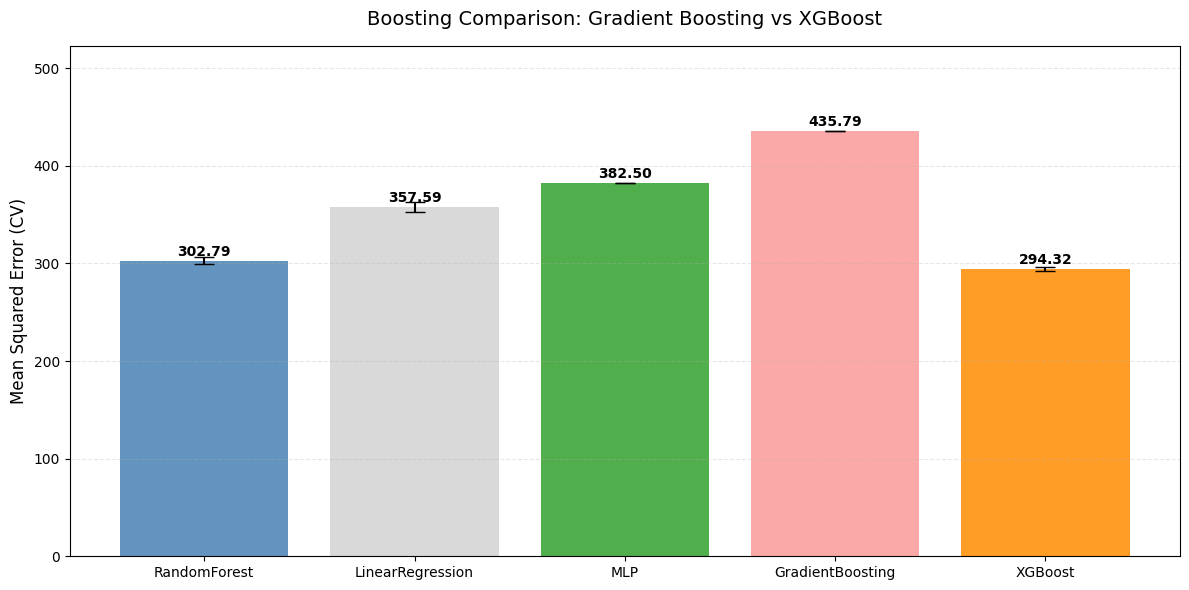

In [31]:
# Load latest results and plot comparison
results_df = pd.read_csv(OUT_DIR / 'baseline_cv_results.csv')
plt.figure(figsize=(12, 6))
# Define colors for each model
colors = {
    'ConstantMean': '#7f8c8d',     # Grey 
    'LinearRegression': '#d3d3d3', 
    'RandomForest': '#4682b4', 
    'GradientBoosting': '#fb9a99', # Light red/pink
    'XGBoost': '#ff8c00'           # Dark orange
}
bar_colors = [colors.get(name, '#33a02c') for name in results_df['name']]

bars = plt.bar(results_df['name'], results_df['mse_mean'], yerr=results_df['mse_std'], capsize=7, 
               color=bar_colors, alpha=0.85)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.2f}', ha='center', va='bottom', fontweight='bold')

plt.title('Boosting Comparison: Gradient Boosting vs XGBoost', fontsize=14, pad=15)
plt.ylabel('Mean Squared Error (CV)', fontsize=12)
plt.ylim(0, max(results_df['mse_mean']) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'model_comparison_boosting.png', dpi=120)
plt.show()

## 7. Final 5-Fold CV With Best Parameters
Re-run a clean 5-fold CV using the same split (seed=42) as notebook 03 so the resulting OOFs are directly comparable / blendable.

In [32]:
# Evaluation on the Local Test set (Section IV.C)
# This provides the unbiased estimate of performance for the final report.

X_test_local = test_local_df.drop(columns=DROP_COLS)
y_test_local = test_local_df[TARGET].astype(float).values

# Align local test
X_test_local = X_test_local.reindex(columns=X.columns)

# We evaluate the Best model found (XGBoost V3 is expected to be best)
best_xgb_pipe = Pipeline(steps=[('prep', preprocessor), ('model', xgb_best)])
best_xgb_pipe.fit(X, y)

test_local_pred = np.clip(best_xgb_pipe.predict(X_test_local), 0, 90)
test_local_mse  = mean_squared_error(y_test_local, test_local_pred)
test_local_mae  = mean_absolute_error(y_test_local, test_local_pred)
test_local_r2   = r2_score(y_test_local, test_local_pred)

print(f"--- Unbiased Local Test Results (XGBoost Best) ---")
print(f"Local Test MSE: {test_local_mse:.3f}")
print(f"Local Test MAE: {test_local_mae:.3f}")
print(f"Local Test R2 : {test_local_r2:.3f}")

# Save these results for the blend
np.save(OUT_DIR / 'test_local_pred_XGBoost.npy', test_local_pred)


--- Unbiased Local Test Results (XGBoost Best) ---
Local Test MSE: 289.193
Local Test MAE: 9.873
Local Test R2 : 0.534


## 8. Final Local Test Evaluation Summary

In [33]:
# Final summary of local test results
print(f'GBM Local Test MSE:    {test_mse_gbm:.3f}')
print(f'XGBoost Local Test MSE: {test_local_mse:.3f}')


GBM Local Test MSE:    387.462
XGBoost Local Test MSE: 289.193


## 9. Feature Importance
XGBoost's built-in 'gain' importance — straightforward to interpret.

Top-25 features by gain:
                                         feature         gain
                               num__h2_flip_rate 60707.074219
                        num__h2_wd_blocking_rate 43515.246094
                                   num__h2_flips 21471.775391
                              num__h2_days_avail 20480.478516
                 num__host_response_time_missing 16809.701172
                           num__h2_blocking_rate 15328.128906
                     num__host_response_rate_num 15033.952148
                                   num__m11_days 14061.654297
                       num__recent_blocking_rate 12944.642578
                    num__recent_wd_blocking_rate 11669.717773
                          num__recent_days_avail 10457.449219
                              num__h2_avail_rate 10097.777344
                               num__traj_recent3  9993.669922
                              num__p5_n_distinct  9761.851562
                           num__q4_new_blocki

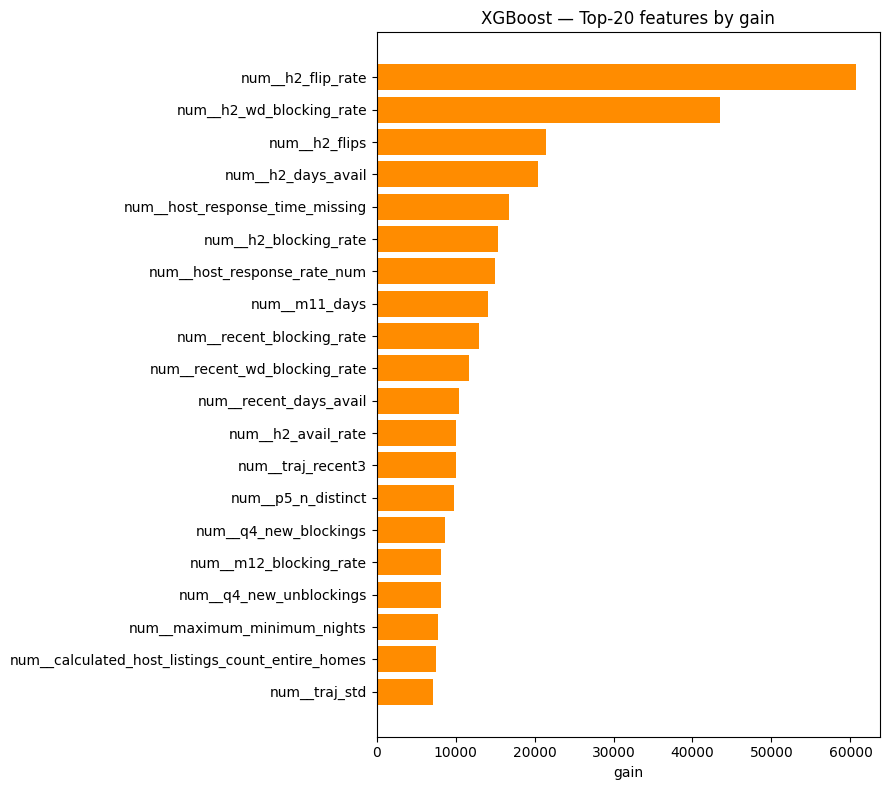

In [34]:
booster = pipe_xgb.named_steps['model'].get_booster()
imp_dict = booster.get_score(importance_type='gain')

# Map XGBoost's f0, f1, ... back to readable feature names from the ColumnTransformer
feature_names = pipe_xgb.named_steps['prep'].get_feature_names_out()
imp_df = pd.DataFrame({
    'feature': [feature_names[int(k[1:])] if k.startswith('f') and k[1:].isdigit() else k
                for k in imp_dict.keys()],
    'gain': list(imp_dict.values()),
}).sort_values('gain', ascending=False)

print('Top-25 features by gain:')
print(imp_df.head(25).to_string(index=False))

top = imp_df.head(20)[::-1]
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top['feature'], top['gain'], color='darkorange')
ax.set_title('XGBoost — Top-20 features by gain')
ax.set_xlabel('gain')
plt.tight_layout(); plt.savefig(OUT_DIR / 'xgb_feature_importance.png', dpi=120); plt.show()

## Summary & Next Step

We now have:
- A tuned **XGBoost** model with optimized hyperparameters.
- CV scores and out-of-fold predictions.
- Insights into feature importance from a boosting perspective.

### → [06_MLP_PyTorch.ipynb](06_MLP_PyTorch.ipynb)
Next we'll:
1. Train a **PyTorch MLP** with the Adam optimizer (Section B.4).
2. See if neural networks can bridge the gap to tree-based ensembles on this task.
